# Neuron ↔ MLE-parameter correlation (2-photon × RL model)

For a chosen saved **MLE fit**, re-evaluate its trial-by-trial latents
(Q-Left, Q-Right, relative Q "Q-val", RewardRate) and ask, **per neuron**,
whether that neuron's per-trial sampling-window max activity correlates with
each latent.

This notebook is a thin config layer over `model/neural_correlate.py` (same
split as `model_compare.ipynb` → `model/compare.py`). Activity comes from the
z-scored + time-normalized sampling-window df; correlation is Pearson, within
session; latents are the before-trial values; brain region is MFC / LFC.

In [25]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

## Config

Declare the model fit and the 2-photon activity source here; everything below
is a call into the backend.

In [35]:
from pathlib import Path

# The saved MLE fit to correlate against (a {subject: payload} pickle).
MODEL_FIT_PATH = "../../data/RLModel/mle_NoiseGain-RewardRate_biasQ-Val (Offset)_Normal(0, 1)_4.8s_dt0.005_mleW1_chi2W0.1.pkl"

# 2-photon sampling-window activity: z-scored + time(width)-normalized,
# window = sampling +0.1s before / +0.1s after. Both the stored trace and the
# np.nanmax activity come from this file.
TWOP_ACTIVITY_PATH = "../../data/2p/normalized_0.1s_before_sampling_0.1s_after_movement.pkl"

# Reuse the per-trial latents already stored inside the fit file (fast, and no
# behavior df needed). Set False to RECOMPUTE them via MLE (expensive; then the
# behavior df is loaded and passed in).
REUSE_FIT_DF = True

# Where saved per-neuron figures + region bars are written.
BASE_SAVE_PATH = "../../results/RLModel/neural_correlate"

# Drop the worst-loss trials (per subject) before correlating? The lapse
# mixture means the worst per-trial loss is not a fixed floor.
EXCLUDE_MAX_LOSS = False

# A neuron counts as "tuned" to a parameter when |Pearson r| >= this. Also the
# threshold used to save ONLY the tuned subset of per-neuron figures.
MIN_ABS_CORR = 0.3
# Neuron-level shuffles for the bar chart's chance baseline + CI + p-value.
N_SHUFFLES = 1000

# Display: how many top-|r| neurons to show; z-score the scatter's activity axis?
TOP_X = 15
ZSCORE_ACTIVITY = False

# Which parameter the example scatter / trace cells use.
PARAM = "Q_val"

# Bin EDGES per parameter for the per-neuron trace-average plot: N edges -> N-1
# bins; a trial joins bin i when edge[i] <= value < edge[i+1] (last bin includes
# its right edge). NOTE: placeholder edges — replace with the intended ones.
PARAM_VALUE_RANGES = {
    "Q_L":        [0, 0.6, 0.7, 0.85, 1.001],
    "Q_R":        [0, 0.6, 0.7, 0.85, 1.001],
    "Q_val":      [-1.001,-0.20, -0.005, 0.005, 0.20, 1.001],
    "RewardRate": [0, 0.4, 0.6, 0.8, 1.001],
}

# Same for the fast/slow drift traces: DV is signed evidence [-1,1]; DVabs is
# evidence magnitude [0,1]. NOTE: placeholder edges — replace as needed.
DRIFT_VALUE_RANGES = {
    "DV":    [-1.001, -0.65, -0.35, -0.001, 0.001, 0.35, 0.65, 1.001],
    "DVabs": [0, 0.35, 0.65, 1.001],
}

## Load

Load the 2-photon activity **first**, take the imaged subjects from it, then
load the MLE latents for **only those subjects** (the fit file usually holds
many un-imaged subjects too). `load_mle_per_trial` reports which latent families
the fit learns (`include_Q` / `include_RewardRate`) and returns only those. With
`REUSE_FIT_DF=True` it reads the per-trial df already stored in the fit (fast, no
behavior df needed).

In [28]:
from .model import neural_correlate as nc

# 1) Load 2-photon activity first, and see which subjects were actually imaged.
df_2p = nc.load_2p_activity(TWOP_ACTIVITY_PATH)
subjects = nc.subjects_in_2p(df_2p)
print("Imaged subjects:", subjects)

# 2) Load the MLE latents for ONLY those subjects. When recomputing we also need
#    the behavior df; when reusing the stored fit df we don't.
df_behavior = None if REUSE_FIT_DF else nc.prepare_behavior_df()
mle_pt, PARAM_KEYS = nc.load_mle_per_trial(
    MODEL_FIT_PATH, df_behavior, subjects=subjects, reuse_fit_df=REUSE_FIT_DF)
# Friendly model name (includes the weighted-Chi² tag) for titles + save paths.
MODEL_NAME = mle_pt.model_label.iloc[0]
print("Model:", MODEL_NAME)
print("Available parameters:", PARAM_KEYS)

Imaged subjects: ['GP4-23', 'GP4-24', 'GP4-28', 'GP4-80', 'GP4-81', 'GP4-85']
  2 requested subject(s) absent from the fit file: ['GP4-23', 'GP4-28']
Model: RewardRate · Q-Val (Offset) · Normal(0, 1) · 4.8s · weighted Chi² (MLE=1, Chi²=0.1)
  subjects loaded: ['GP4-24', 'GP4-80', 'GP4-81', 'GP4-85']
  mode: reuse stored mle_df
  include_Q=True  include_RewardRate=True
  Correlatable parameters: Q_L, Q_R, Q_val, RewardRate
Model: RewardRate · Q-Val (Offset) · Normal(0, 1) · 4.8s · weighted Chi² (MLE=1, Chi²=0.1)
Available parameters: ['Q_L', 'Q_R', 'Q_val', 'RewardRate']


## Intermediate table + per-neuron correlations

`table` is one row per (neuron, matched trial): max activity, the full
time-normalized trace, and the latents. `corr_df` is one row per neuron with
`{param}_r` / `{param}_p` (within-session Pearson).

In [29]:
table = nc.build_neuron_trial_table(df_2p, mle_pt, PARAM_KEYS,
                                    exclude_max_loss=EXCLUDE_MAX_LOSS)
print(f"{table.long_trace_id.nunique()} neurons · {len(table)} (neuron×trial) rows")
table.head()

584 neurons · 131628 (neuron×trial) rows


,trace_id,long_trace_id,BrainRegion,ShortName,TrialNumber,max_activity,trace,epochs_ranges,epochs_names,DV,DVabs,quantile_idx,Q_L,Q_R,Q_val,RewardRate
0,1,GP4_24_s4_L85_D250_M2_1,MFC,GP4_24_s4_L85_D250_M2,119,-0.049659,"[-0.4802003, -0.4641595, -0.4109047, -0.403866...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.872218,0.816768,0.014263,0.722547
1,2,GP4_24_s4_L85_D250_M2_2,MFC,GP4_24_s4_L85_D250_M2,119,-0.197314,"[-0.8525737, -0.6850297, -0.47221366, -0.33689...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.872218,0.816768,0.014263,0.722547
2,3,GP4_24_s4_L85_D250_M2_3,MFC,GP4_24_s4_L85_D250_M2,119,-0.338939,"[-0.58463955, -0.5942389, -0.71961886, -0.8497...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.872218,0.816768,0.014263,0.722547
3,5,GP4_24_s4_L85_D250_M2_5,MFC,GP4_24_s4_L85_D250_M2,119,-0.017965,"[-0.28918448, -0.13945785, -0.023446966, -0.01...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.872218,0.816768,0.014263,0.722547
4,9,GP4_24_s4_L85_D250_M2_9,MFC,GP4_24_s4_L85_D250_M2,119,0.857584,"[-0.2088601, -0.30529004, -0.1775805, 0.186450...","((0, 2), (3, 29), (30, 32))","[-0.1s Sampling, Sampling, Movement to Lateral...",-0.5,0.5,3,0.872218,0.816768,0.014263,0.722547


In [30]:
corr_df = nc.compute_neuron_correlations(table, PARAM_KEYS)
corr_df.head()

,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,Q_L_r,Q_L_p,Q_R_r,Q_R_p,Q_val_r,Q_val_p,RewardRate_r,RewardRate_p
0,1,GP4_24_s4_L85_D250_M2_1,MFC,GP4_24_s4_L85_D250_M2,179,-0.119423,0.111322,0.121372,0.105563,-0.145589,0.051826,0.109823,0.143341
1,10,GP4_24_s4_L85_D250_M2_10,MFC,GP4_24_s4_L85_D250_M2,179,-0.293183,0.000068,-0.268066,0.000286,-0.028336,0.706519,-0.144331,0.053906
2,114,GP4_24_s4_L85_D250_M2_114,MFC,GP4_24_s4_L85_D250_M2,179,-0.127280,0.089532,0.284689,0.000112,-0.259654,0.000448,0.082493,0.272281
3,12,GP4_24_s4_L85_D250_M2_12,MFC,GP4_24_s4_L85_D250_M2,179,-0.166826,0.025615,-0.025613,0.733606,-0.097657,0.193423,-0.041556,0.580722
4,13,GP4_24_s4_L85_D250_M2_13,MFC,GP4_24_s4_L85_D250_M2,179,-0.353494,0.000001,-0.244538,0.000970,-0.082757,0.270747,-0.140618,0.060450


## Per-neuron scatters (activity vs parameter)

Top-`TOP_X` neurons by `|r|` for `PARAM`. y = Neuron Activity, x = the latent.

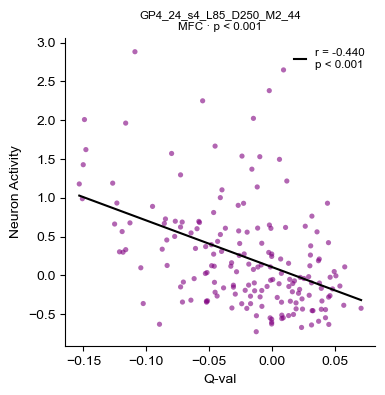

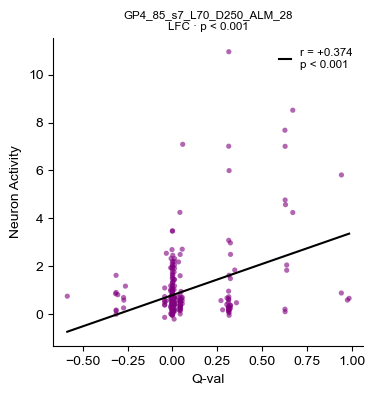

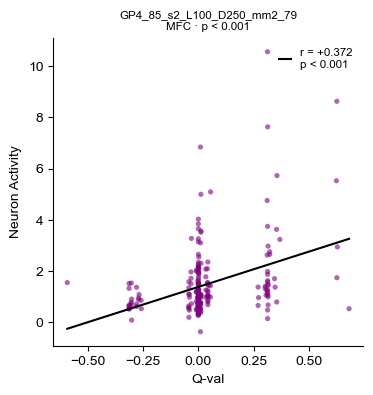

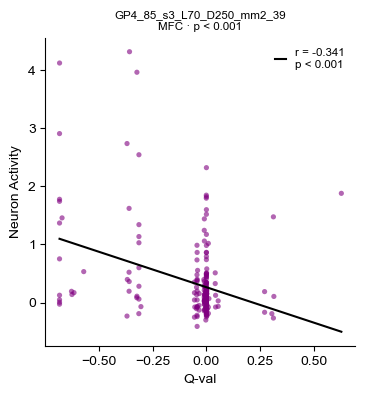

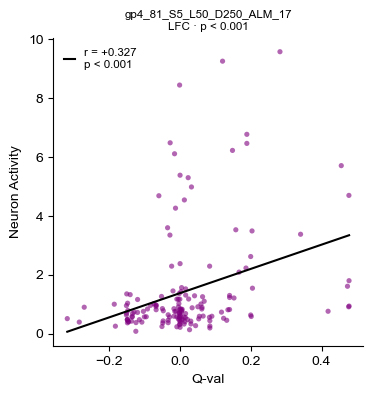

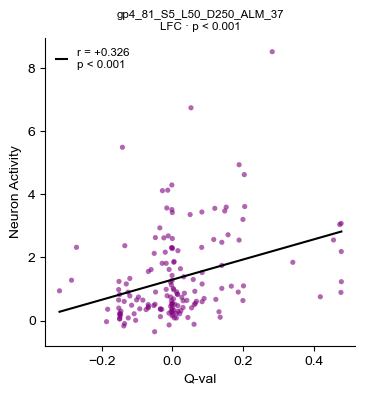

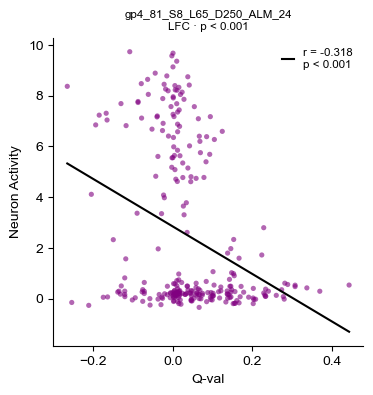

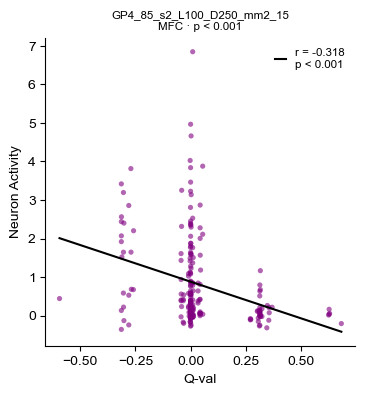

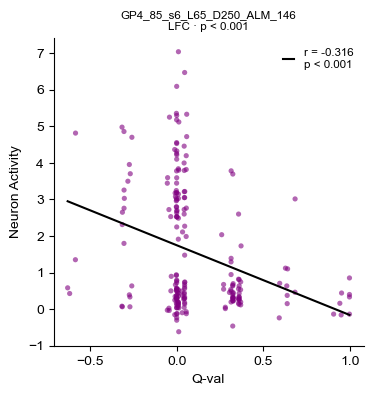

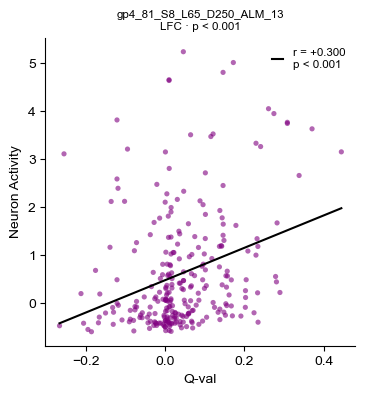

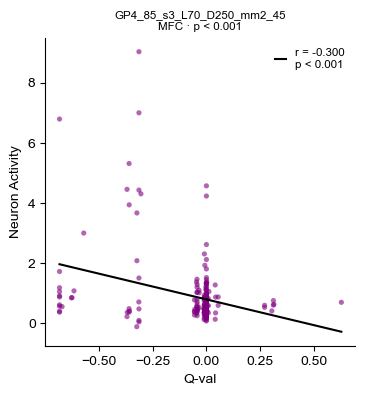

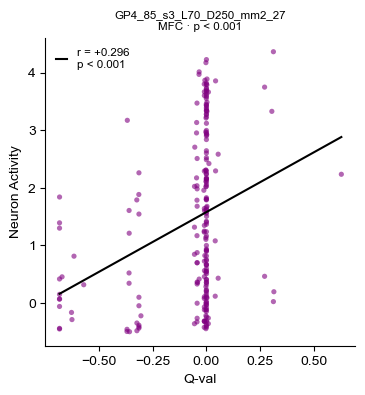

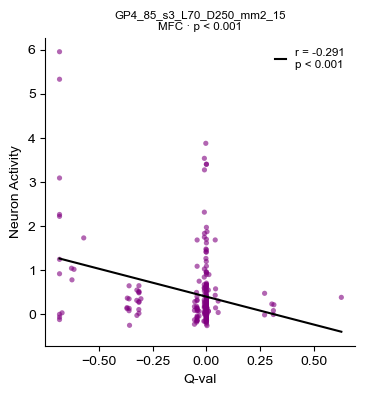

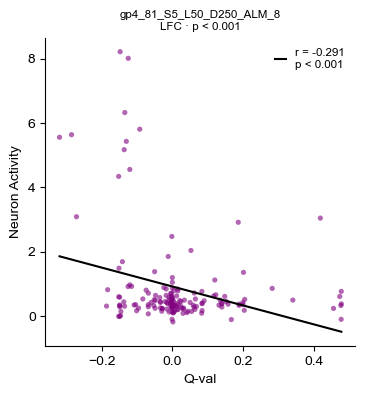

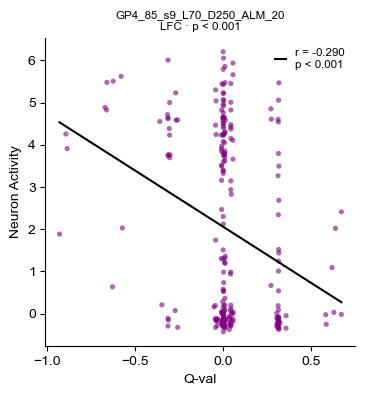

In [23]:
_ = nc.plot_neuron_results(table, corr_df, PARAM, mode="display",
                           top_x=TOP_X, zscore=ZSCORE_ACTIVITY)

In [21]:
# Save each TUNED neuron's scatter (|r| >= MIN_ABS_CORR) for EVERY parameter:
#   {BASE_SAVE_PATH}/{model}/traces/{param}/{signed_r}_{long_name}[_region].svg
for key in PARAM_KEYS:
    nc.plot_neuron_results(table, corr_df, key, mode="save",
                           zscore=ZSCORE_ACTIVITY, min_abs_corr=MIN_ABS_CORR,
                           save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

Saved 25 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\traces\Q_L
Saved 45 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\traces\Q_R
Saved 9 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\traces\Q_val
Saved 26 neuron plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\traces\RewardRate


## Per-neuron trace averages by parameter value range

For each neuron, the time-normalized trace is averaged (mean ± SEM) within each
value range of `PARAM` (from `PARAM_VALUE_RANGES`), all overlaid in one axes and
gradient-coloured (pale → the parameter's bar colour). Dashed lines mark
sampling start and movement start. `mode="display"` shows the top-`TOP_X`
neurons; `mode="save"` writes the tuned subset (`|r| >= MIN_ABS_CORR`) under
`{model}/param_traces/{param}/`.

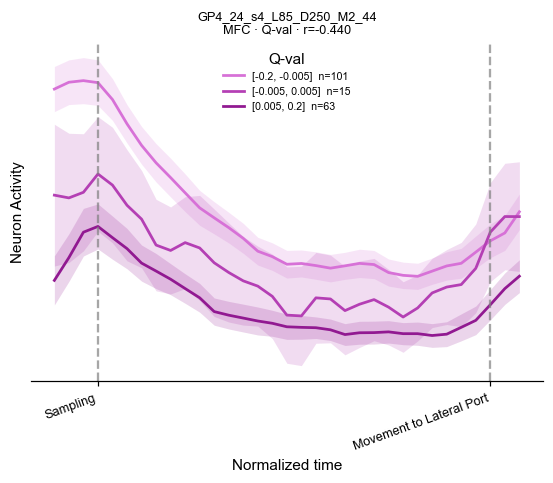

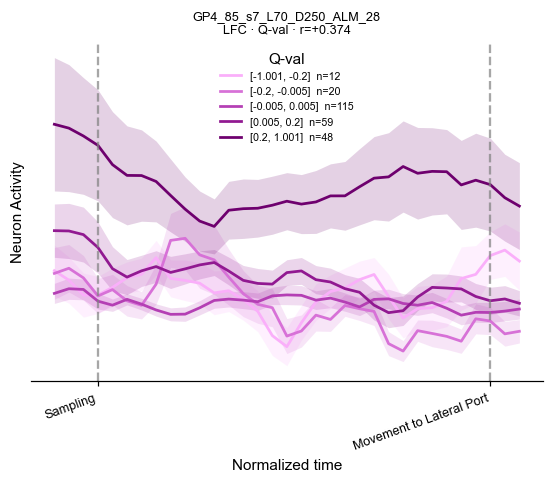

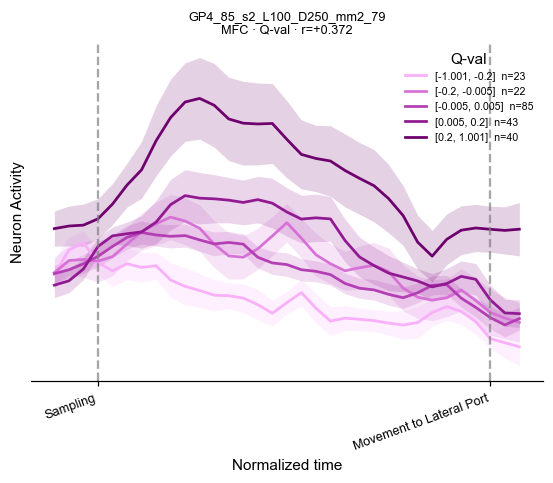

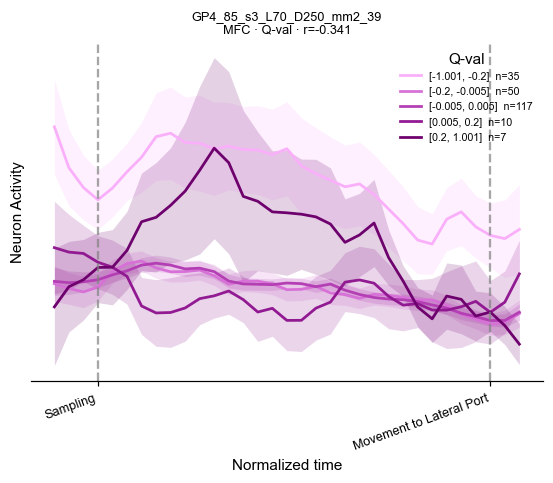

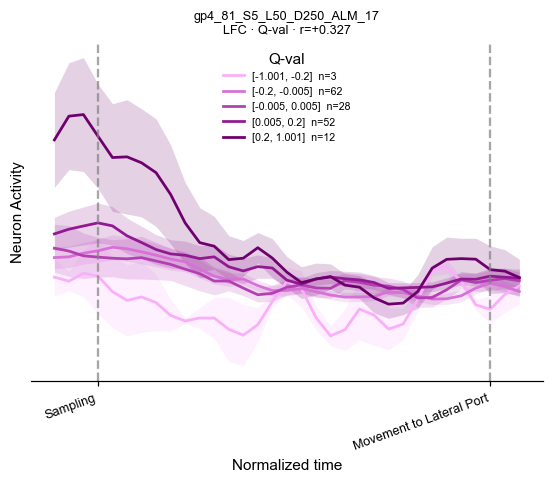

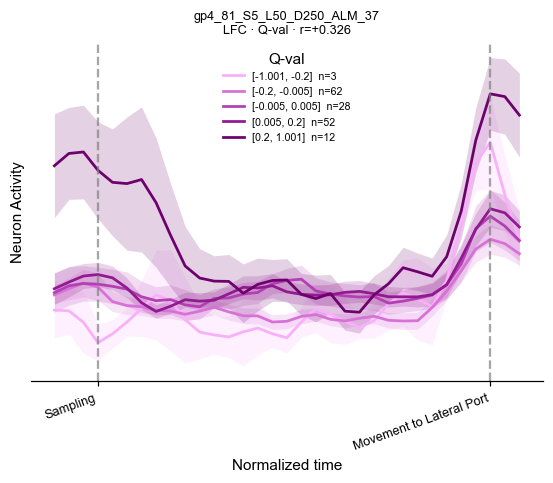

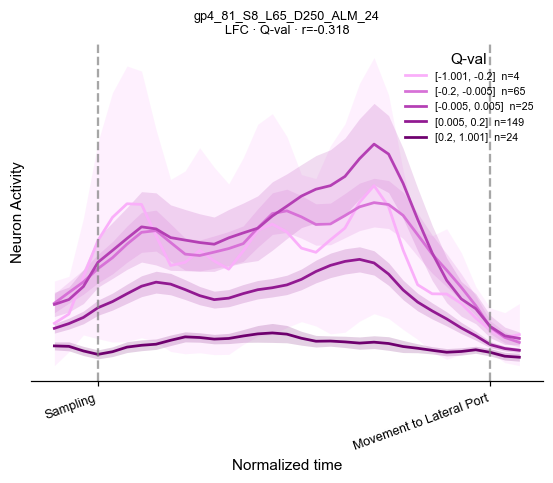

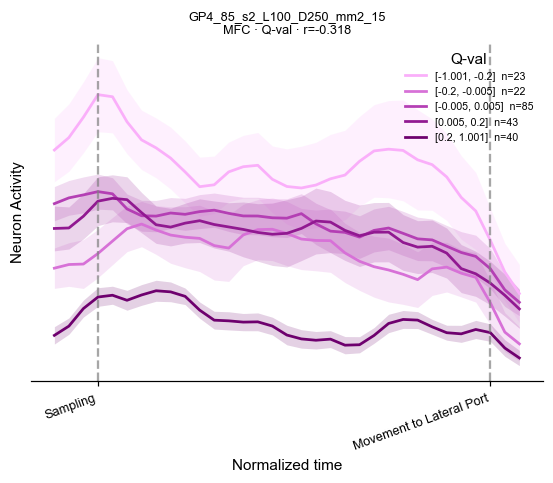

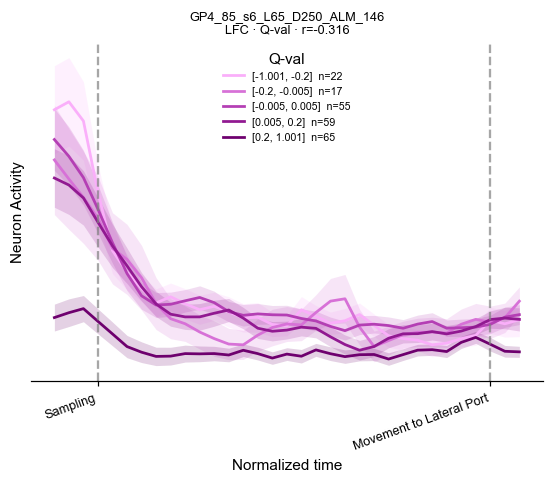

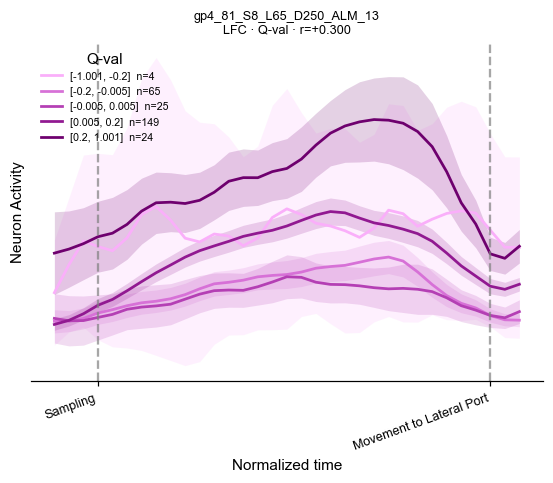

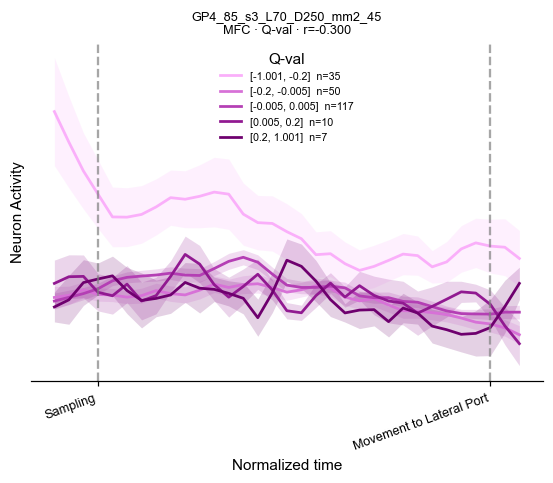

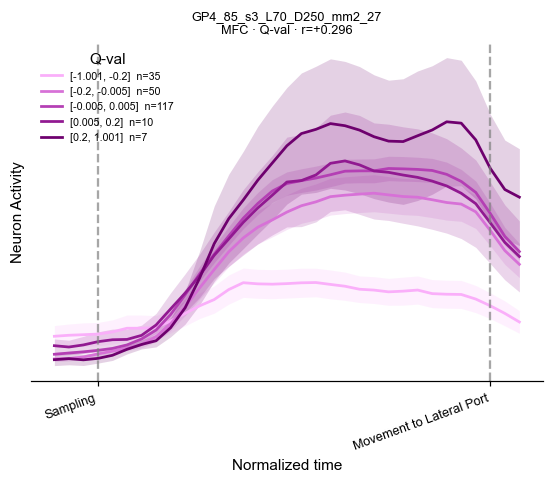

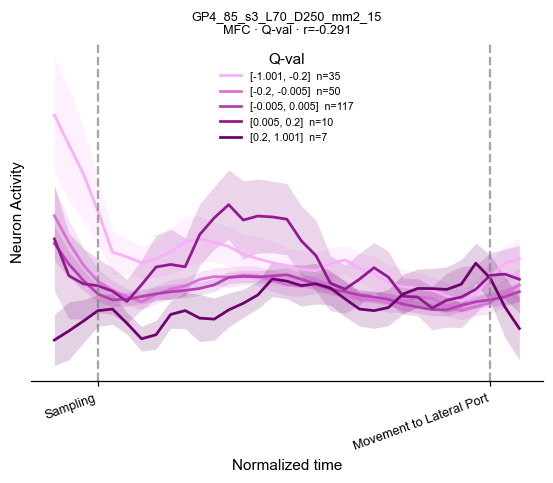

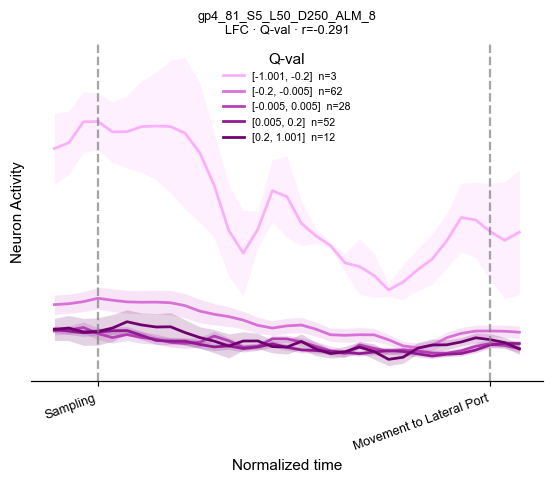

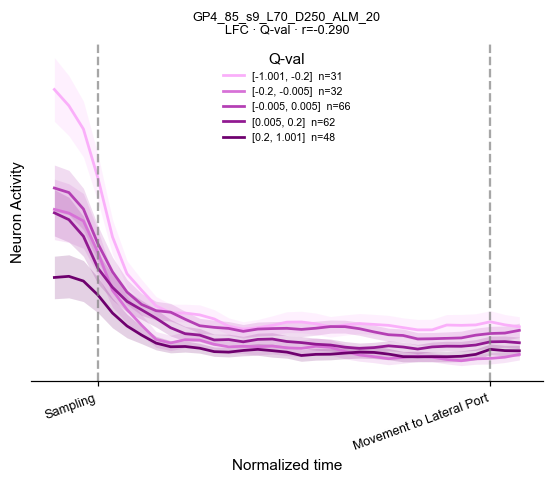

In [24]:
# Display the top-TOP_X tuned neurons' range-averaged traces for PARAM:
# _PARAM = "Q_R"
_PARAM = PARAM
_ = nc.plot_neuron_param_traces(table, corr_df, _PARAM, PARAM_VALUE_RANGES[_PARAM],
                                mode="display", top_x=TOP_X)


In [20]:
# Save the tuned subset for every parameter:
#   {BASE_SAVE_PATH}/{model}/param_traces/{param}/{signed_r}_{long_name}[_region].svg
for key in PARAM_KEYS:
    nc.plot_neuron_param_traces(table, corr_df, key, PARAM_VALUE_RANGES[key],
                                mode="save", min_abs_corr=MIN_ABS_CORR,
                                save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

Saved 25 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\param_traces\Q_L
Saved 45 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\param_traces\Q_R
Saved 9 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\param_traces\Q_val
Saved 26 neuron trace plots -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\param_traces\RewardRate


## Fraction-tuned bars (per brain region, vs shuffle)

One coloured bar per parameter = the % of tuned neurons (session mean ± SEM),
with a grey **shuffle chance** sub-bar (+ CI) from `N_SHUFFLES` neuron-level
permutations of each neuron's activity, and a permutation p-value above each
bar. `by_region=True` gives one panel per MFC/LFC; `by_region=False` pools
everything. Always shown; set `save=True` to also write the figure + summary
table under `{model}/tuning_bars/`.

Saved tuning bars -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\tuning_bars


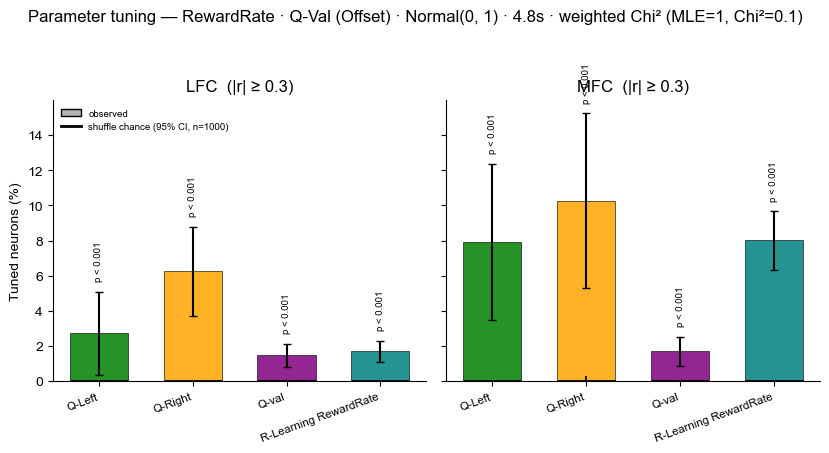

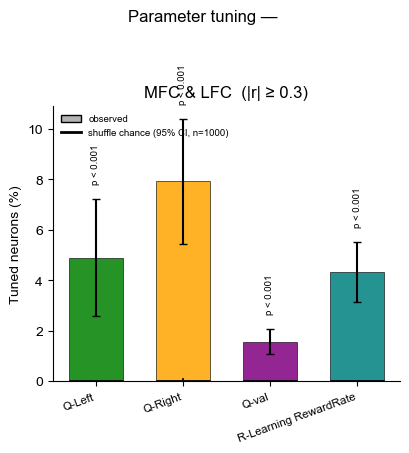

,BrainRegion,param,observed_pct,observed_sem,shuffle_pct,ci2.5,ci97.5,n_sessions,p_vs_shuffle
0,LFC,Q_L,2.721088,2.348335,0.006833,0.0,0.000000,7,0.000999
1,LFC,Q_R,6.241377,2.516567,0.003545,0.0,0.000000,7,0.000999
2,LFC,Q_val,1.465543,0.658066,0.006253,0.0,0.000000,7,0.000999
3,LFC,RewardRate,1.695957,0.611213,0.004153,0.0,0.000000,7,0.000999
4,MFC,Q_L,7.933333,4.442722,0.001600,0.0,0.000000,5,0.000999
5,MFC,Q_R,10.275000,4.959902,0.010625,0.0,0.266667,5,0.000999
6,MFC,Q_val,1.691667,0.813472,0.000933,0.0,0.000000,5,0.000999
7,MFC,RewardRate,8.005556,1.655528,0.004850,0.0,0.000000,5,0.000999


In [22]:
# One bar per parameter, split by brain region, with the neuron-level shuffle
# baseline + permutation p-value. Needs `table` (per-trial data) for the shuffle.
summary = nc.plot_region_bars(corr_df, table, min_abs_corr=MIN_ABS_CORR,
                              n_shuffles=N_SHUFFLES, by_region=True, save=True ,
                              save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
# ... and pooled across regions (everything together):
_ = nc.plot_region_bars(corr_df, table, min_abs_corr=MIN_ABS_CORR, save=False,
                        n_shuffles=N_SHUFFLES, by_region=False)
summary

# Fast vs slow: drift-correlated neurons

Same tuned criterion (Pearson r of per-trial max activity vs the drift value,
`|r| >= MIN_ABS_CORR`), but the drift value is the trial's **DV** (signed
evidence) and, separately, **DVabs** (=|DV|). Correlations are computed **within**
the fast (`quantile_idx==1`) and slow (`quantile_idx==3`) trial subsets
separately. The summary bars compare each region — and all regions pooled — fast
vs slow (session mean ± SEM, no shuffle).

In [36]:
# Per-neuron DV / DVabs correlations, computed within the fast and slow subsets.
corr_fast, corr_slow = nc.drift_correlations(table)
print("fast neurons:", len(corr_fast), " slow neurons:", len(corr_slow))
corr_fast.head()

fast neurons: 584  slow neurons: 584


,trace_id,long_trace_id,BrainRegion,ShortName,n_trials,DV_r,DV_p,DVabs_r,DVabs_p
0,1,GP4_24_s4_L85_D250_M2_1,MFC,GP4_24_s4_L85_D250_M2,60,-0.342995,0.007300,0.182082,0.163800
1,10,GP4_24_s4_L85_D250_M2_10,MFC,GP4_24_s4_L85_D250_M2,60,-0.046757,0.722773,0.224234,0.085000
2,114,GP4_24_s4_L85_D250_M2_114,MFC,GP4_24_s4_L85_D250_M2,60,0.063333,0.630702,-0.073248,0.578081
3,12,GP4_24_s4_L85_D250_M2_12,MFC,GP4_24_s4_L85_D250_M2,60,0.103604,0.430840,-0.196349,0.132684
4,13,GP4_24_s4_L85_D250_M2_13,MFC,GP4_24_s4_L85_D250_M2,60,-0.082708,0.529836,0.169391,0.195711


## Fast-vs-slow summary bars

Per-session % drift-correlated neurons, fast (tomato) vs slow (goldenrod), for
DV and DVabs. `by_region=True` → one fast/slow pair per MFC/LFC (4 bars);
`by_region=False` → all regions pooled (2 bars). Bars are session mean ± SEM, no
shuffle.

	LFC: fast 2.36±1.08% (7 sess) | slow 6.07±1.74% (7 sess)
	MFC: fast 2.49±1.01% (5 sess) | slow 8.46±3.44% (5 sess)
Saved fast/slow bars -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\fast_slow_bars\DV


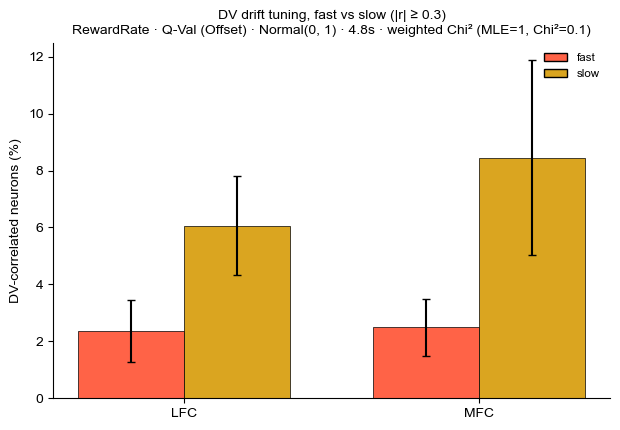

	MFC & LFC: fast 2.41±0.73% (12 sess) | slow 7.06±1.70% (12 sess)
Saved fast/slow bars -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\fast_slow_bars\DV


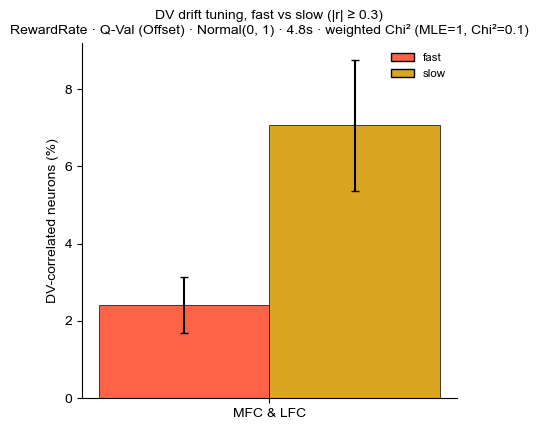

	LFC: fast 1.26±1.01% (7 sess) | slow 2.42±1.41% (7 sess)
	MFC: fast 0.00±0.00% (5 sess) | slow 4.54±2.47% (5 sess)
Saved fast/slow bars -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\fast_slow_bars\DVabs


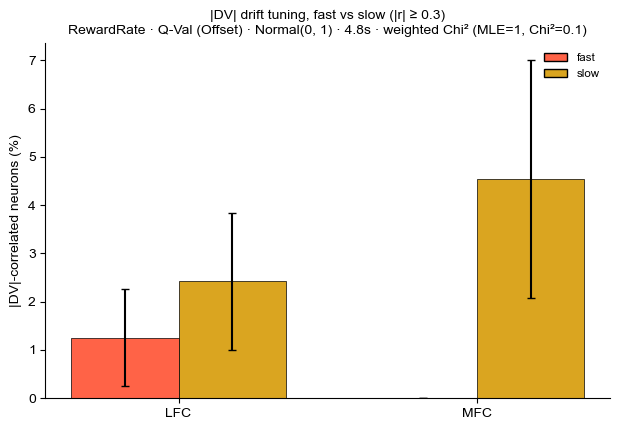

	MFC & LFC: fast 0.73±0.60% (12 sess) | slow 3.31±1.29% (12 sess)
Saved fast/slow bars -> ..\..\results\RLModel\neural_correlate\RewardRate - Q-Val (Offset) - Normal(0, 1) - 4.8s - weighted Chi² (MLE=1, Chi²=0.1)\fast_slow_bars\DVabs


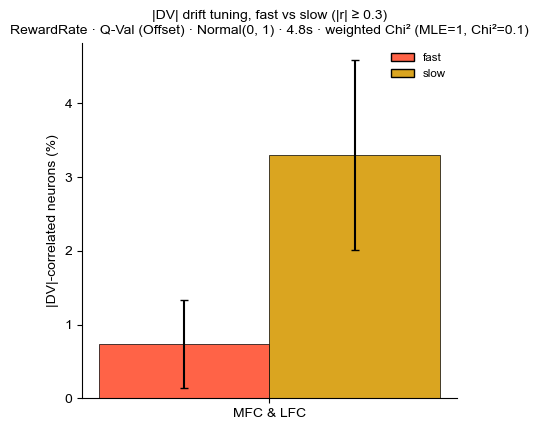

In [39]:
# Fast-vs-slow summary bars: per region (4 bars) and all-regions pooled (2 bars),
# for DV and for DVabs. Set save=True to also write the figure + summary csv.
for drift in ("DV", "DVabs"):
    nc.plot_fast_slow_bars(corr_fast, corr_slow, drift, min_abs_corr=MIN_ABS_CORR,
                           by_region=True, save=True,
                           save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)
    nc.plot_fast_slow_bars(corr_fast, corr_slow, drift, min_abs_corr=MIN_ABS_CORR,
                           by_region=False, save=True,
                           save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Per-neuron fast/slow scatters

Fast (tomato) and slow (goldenrod) trials overlaid on one axes, each with its
own fit line + r/p. Neurons ranked by `max(|r_fast|, |r_slow|)`; display shows
the top-`TOP_X`, save writes the drift-correlated subset under
`{model}/drift_scatter/{drift}/`.

In [ ]:
# Per-neuron scatters, fast (tomato) & slow (goldenrod) overlaid, top-TOP_X by
# max(|r_fast|, |r_slow|). Each speed gets its own fit line + r/p in the legend.
_DRIFT = "DV"   # or "DVabs"
_ = nc.plot_neuron_fastslow_scatter(table, corr_fast, corr_slow, _DRIFT,
                                    mode="display", top_x=TOP_X)

# Save the drift-correlated subset (max(|r_fast|,|r_slow|) >= MIN_ABS_CORR):
#   {BASE_SAVE_PATH}/{model}/drift_scatter/{drift}/f{rf}_s{rs}_{long_name}[_region].svg
# for drift in ("DV", "DVabs"):
#     nc.plot_neuron_fastslow_scatter(table, corr_fast, corr_slow, drift,
#                                     mode="save", min_abs_corr=MIN_ABS_CORR,
#                                     save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)

## Per-neuron fast/slow traces

Two-panel (Fast | Slow) time-normalized traces, averaged within each
`DRIFT_VALUE_RANGES` bin and gradient-coloured. For the signed **DV**, the
gradient encodes only the range's magnitude (so ±1 share a shade) and the
negative-DV ranges are drawn dashed; **DVabs** is a plain light→dark gradient.

In [ ]:
# Per-neuron normalized traces, Fast | Slow two-panel, gradient by DRIFT range.
_DRIFT = "DV"   # or "DVabs"
_ = nc.plot_neuron_fastslow_traces(table, corr_fast, corr_slow, _DRIFT,
                                   DRIFT_VALUE_RANGES[_DRIFT],
                                   mode="display", top_x=TOP_X)

# Save the drift-correlated subset under {model}/drift_traces/{drift}/:
for drift in ("DV", "DVabs"):
    nc.plot_neuron_fastslow_traces(table, corr_fast, corr_slow, drift,
                                   DRIFT_VALUE_RANGES[drift], mode="save",
                                   min_abs_corr=MIN_ABS_CORR,
                                   save_root=BASE_SAVE_PATH, model_name=MODEL_NAME)